In [1]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.decomposition import PCA

import joblib

# sklearn's HTML estimator repr reads estimator.js with the locale default
# codec (cp874 here), which raises UnicodeDecodeError on Windows.
# Plain-text repr avoids it.
sklearn.set_config(display='text')


In [2]:
data = np.load('C:\\Users\\emper\\Desktop\\ICRA2026\\locomotion_learning_information-theory\\data\\weight_dynamic\\hebb-pos_act_model0-weight-num0.npz')

In [3]:
layer0 = data['arr_0'].reshape(data['arr_0'].shape[0], -1)
layer1 = data['arr_1'].reshape(data['arr_1'].shape[0], -1)
layer2 = data['arr_2'].reshape(data['arr_2'].shape[0], -1)
print(f"layer0.shape: {layer0.shape}, layer1.shape: {layer1.shape}, layer2.shape: {layer2.shape}")

flatten_weight = np.concatenate([layer0, layer1, layer2],axis=1)
print(f"flatten_weight.shape: {flatten_weight.shape}")

layer0.shape: (1000, 4864), layer1.shape: (1000, 8192), layer2.shape: (1000, 1216)
flatten_weight.shape: (1000, 14272)


In [ ]:
pca = PCA(n_components=3)
# ----- Fit , then transform -----
# pca.fit(flatten_weight)
# weight_pcs = pca.transform(flatten_weight)

# ----- Fit and transform in one step -----
# weight_pcs = pca.fit_transform(flatten_weight[:,:500])
weight_pcs = pca.fit_transform(flatten_weight)
# pca.fit(flatten_weight)
# joblib.dump(pca, 'pca_model.joblib')

print(f"weight_pcs.shape: {weight_pcs.shape}")
print(f"explained variance ratio: {pca.explained_variance_ratio_}")
print(f"cumulative: {pca.explained_variance_ratio_.sum():.4f}")


['pca_model.joblib']

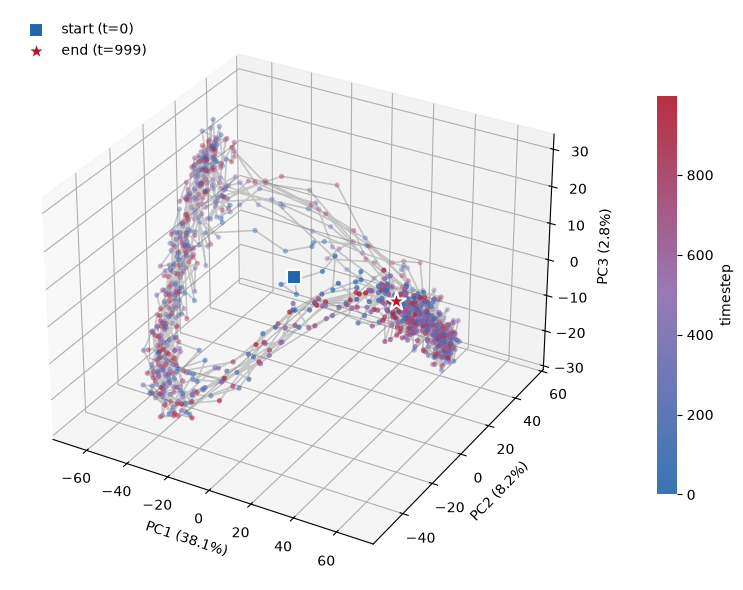

In [45]:
from matplotlib.colors import LinearSegmentedColormap

# Blue (early) -> red (late). Routed through purple instead of white so the
# mid-trajectory points keep their chroma on a white background.
time_cmap = LinearSegmentedColormap.from_list(
    "early_late", ["#2166AC", "#8C6BB1", "#B2182B"]
)

n = weight_pcs.shape[0]
t = np.arange(n)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

# The last sample sits inside a dense cluster; without this, 3d depth sorting
# buries the end marker and zorder is ignored.
ax.computed_zorder = False

# -------- Data --------

ax.plot(
    weight_pcs[:, 0], weight_pcs[:, 1], weight_pcs[:, 2],
    color="gray", linewidth=1.2, alpha=0.4, zorder=0
)

sc = ax.scatter(
    weight_pcs[:, 0], weight_pcs[:, 1], weight_pcs[:, 2],
    c=t, cmap=time_cmap, s=14, marker="o",
    linewidths=0, alpha=0.9, zorder=1,
)

# -------- First , Last markers --------
first, last = weight_pcs[0], weight_pcs[-1]
ax.scatter(*first, c=[time_cmap(0.0)], s=100, marker="s",
           edgecolors="white", linewidths=1.5, depthshade=False,
           label="start (t=0)", zorder=10)
ax.scatter(*last, c=[time_cmap(1.0)], s=200, marker="*",
           edgecolors="white", linewidths=1.5, depthshade=False,
           label=f"end (t={n - 1})", zorder=11)

# -------- Label --------
evr = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({evr[0]:.1%})")
ax.set_ylabel(f"PC2 ({evr[1]:.1%})")
ax.set_zlabel(f"PC3 ({evr[2]:.1%})")

ax.legend(loc="upper left", frameon=False)


# -------- Color --------
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("timestep")
cbar.outline.set_visible(False)

fig.tight_layout()
plt.show()


In [46]:
from matplotlib import animation
from pathlib import Path

# ---- animation settings -------------------------------------------------
STRIDE = 5      # keep every Nth sample -> fewer, faster frames
TRAIL = 80      # how many past samples stay visible behind the head
FPS = 20
ROTATE = 40     # total azimuth sweep in degrees (0 disables rotation)
OUT_DIR = Path.cwd()   # .gif lands next to this notebook
# -------------------------------------------------------------------------

frames = np.arange(0, n, STRIDE)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.computed_zorder = False

# Faint full cloud so the shape of the space stays visible the whole time.
ax.scatter(weight_pcs[:, 0], weight_pcs[:, 1], weight_pcs[:, 2],
           c="0.78", s=7, linewidths=0, depthshade=False, zorder=0)

trail = ax.scatter([], [], [], s=30, linewidths=0, depthshade=False, zorder=5)
head = ax.scatter([], [], [], s=340, marker="o", edgecolors="white",
                  linewidths=1.8, depthshade=False, zorder=20)

ax.scatter(*weight_pcs[0], c=[time_cmap(0.0)], s=200, marker="s",
           edgecolors="white", linewidths=1.5, depthshade=False,
           label="start (t=0)", zorder=10)
ax.scatter(*weight_pcs[-1], c=[time_cmap(1.0)], s=420, marker="*",
           edgecolors="white", linewidths=1.5, depthshade=False,
           label=f"end (t={n - 1})", zorder=11)

evr = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({evr[0]:.1%})")
ax.set_ylabel(f"PC2 ({evr[1]:.1%})")
ax.set_zlabel(f"PC3 ({evr[2]:.1%})")
ax.set_xlim(weight_pcs[:, 0].min(), weight_pcs[:, 0].max())
ax.set_ylim(weight_pcs[:, 1].min(), weight_pcs[:, 1].max())
ax.set_zlim(weight_pcs[:, 2].min(), weight_pcs[:, 2].max())
ax.legend(loc="upper left", frameon=False)

sm = plt.cm.ScalarMappable(cmap=time_cmap, norm=plt.Normalize(0, n - 1))
cbar = fig.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("timestep")
cbar.outline.set_visible(False)

clock = ax.text2D(0.98, 0.02, "", transform=ax.transAxes,
                  ha="right", va="bottom", fontsize=11, color="0.35")

azim0 = ax.azim


def update(i):
    lo = max(0, i - TRAIL)
    seg = weight_pcs[lo:i + 1]
    trail._offsets3d = (seg[:, 0], seg[:, 1], seg[:, 2])
    trail.set_color(time_cmap(np.linspace(lo, i, len(seg)) / max(n - 1, 1)))
    trail.set_alpha(0.85)

    pt = weight_pcs[i]
    head._offsets3d = ([pt[0]], [pt[1]], [pt[2]])
    head.set_color([time_cmap(i / max(n - 1, 1))])

    if ROTATE:
        ax.view_init(elev=ax.elev, azim=azim0 + ROTATE * i / max(n - 1, 1))

    clock.set_text(f"t = {i}")
    return trail, head, clock


anim = animation.FuncAnimation(fig, update, frames=frames,
                               interval=1000 / FPS, blit=False)

gif_path = OUT_DIR / "pca_trajectory.gif"
anim.save(gif_path, writer=animation.PillowWriter(fps=FPS), dpi=90)
print(f"wrote {gif_path}")

# MP4 needs ffmpeg on PATH; skipped cleanly when it is not installed.
if animation.FFMpegWriter.isAvailable():
    mp4_path = OUT_DIR / "pca_trajectory.mp4"
    anim.save(mp4_path, writer=animation.FFMpegWriter(fps=FPS, bitrate=2400), dpi=140)
    print(f"wrote {mp4_path}")
else:
    print("ffmpeg not found - GIF only. `conda install ffmpeg` or add it to PATH for MP4.")

plt.close(fig)


wrote c:\Users\emper\Desktop\ICRA2026\locomotion_learning_information-theory\weight_analysis\pca_trajectory.gif
ffmpeg not found - GIF only. `conda install ffmpeg` or add it to PATH for MP4.
